# 🧠 Logistic Regression From Scratch
### A complete learning notebook — from intuition to multi-class implementation

---

**What you'll build in this notebook:**
1. The sigmoid function — the core of logistic regression
2. Binary logistic regression from scratch
3. Training with gradient descent
4. Decision boundaries and visualizations
5. Multinomial (multi-class) logistic regression with Softmax
6. Evaluation metrics from scratch

**Pre-requisites:** Basic Python, NumPy, some familiarity with linear algebra

---

## 📦 Imports

We use **only** NumPy for math. Matplotlib is only for visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# For reproducibility
np.random.seed(42)

# Clean plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 13
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ All imports ready. Let's build Logistic Regression from scratch!")

✅ All imports ready. Let's build Logistic Regression from scratch!


---

## 🧩 Part 1: Why Not Linear Regression?

Before logistic regression, let's understand **why linear regression fails for classification**.

Linear regression predicts a continuous value: `ŷ = wX + b`

For classification, we need probabilities — values between **0 and 1**.
Linear regression can output 1.7, -0.4... which makes no sense as a probability.

**The key insight:** We need to *squeeze* any real number into the range (0, 1).
That's exactly what the **Sigmoid function** does.

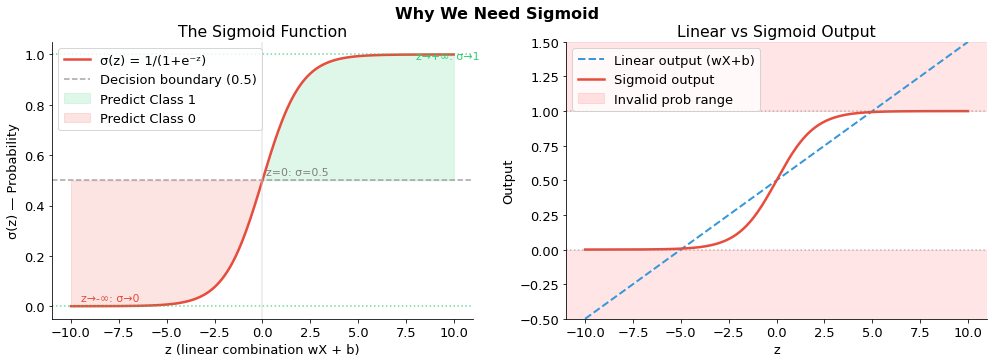

Key properties of Sigmoid:
  σ(0)  = 0.50   ← always exactly 0.5
  σ(10) = 1.0000 ← approaches 1
  σ(-10)= 0.0000 ← approaches 0


In [2]:
# ============================================================
# THE SIGMOID FUNCTION
# Formula: σ(z) = 1 / (1 + e^(-z))
# ============================================================

def sigmoid(z):
    """
    Maps any real number to the range (0, 1).
    
    Parameters:
        z : float or np.array — the linear combination (wX + b)
    Returns:
        float or np.array — probability between 0 and 1
    """
    return 1 / (1 + np.exp(-z))


# --- Visualize Sigmoid ---
z = np.linspace(-10, 10, 300)
sig = sigmoid(z)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Sigmoid curve
ax = axes[0]
ax.plot(z, sig, color='#e74c3c', linewidth=2.5, label='σ(z) = 1/(1+e⁻ᶻ)')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Decision boundary (0.5)')
ax.axhline(1.0, color='#2ecc71', linestyle=':', alpha=0.7)
ax.axhline(0.0, color='#2ecc71', linestyle=':', alpha=0.7)
ax.axvline(0, color='lightgray', linestyle='-', alpha=0.5)
ax.fill_between(z, 0.5, sig, where=(sig >= 0.5), alpha=0.15, color='#2ecc71', label='Predict Class 1')
ax.fill_between(z, sig, 0.5, where=(sig < 0.5), alpha=0.15, color='#e74c3c', label='Predict Class 0')
ax.set_xlabel('z (linear combination wX + b)')
ax.set_ylabel('σ(z) — Probability')
ax.set_title('The Sigmoid Function')
ax.legend()
ax.set_ylim(-0.05, 1.05)

# Add annotations
ax.annotate('z→+∞: σ→1', xy=(8, 0.98), fontsize=11, color='#2ecc71')
ax.annotate('z→-∞: σ→0', xy=(-9.5, 0.02), fontsize=11, color='#e74c3c')
ax.annotate('z=0: σ=0.5', xy=(0.2, 0.52), fontsize=11, color='gray')

# Right: Compare with linear
ax2 = axes[1]
ax2.plot(z, z * 0.1 + 0.5, color='#3498db', linewidth=2, linestyle='--', label='Linear output (wX+b)')
ax2.plot(z, sig, color='#e74c3c', linewidth=2.5, label='Sigmoid output')
ax2.axhspan(1.0, 1.5, alpha=0.1, color='red', label='Invalid prob range')
ax2.axhspan(-0.5, 0, alpha=0.1, color='red')
ax2.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
ax2.axhline(0.0, color='gray', linestyle=':', alpha=0.5)
ax2.set_xlabel('z')
ax2.set_ylabel('Output')
ax2.set_title('Linear vs Sigmoid Output')
ax2.set_ylim(-0.5, 1.5)
ax2.legend()

plt.tight_layout()
plt.suptitle('Why We Need Sigmoid', fontsize=16, y=1.01, fontweight='bold')
plt.show()

# Key properties
print("Key properties of Sigmoid:")
print(f"  σ(0)  = {sigmoid(0):.2f}   ← always exactly 0.5")
print(f"  σ(10) = {sigmoid(10):.4f} ← approaches 1")
print(f"  σ(-10)= {sigmoid(-10):.4f} ← approaches 0")

---

## 🔢 Part 2: The Logistic Regression Model

Logistic regression is a **two-step process**:

```
Step 1 (Linear):  z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b  =  W·X + b
Step 2 (Sigmoid): ŷ = σ(z) = 1 / (1 + e^(-z))
```

Interpreted as: **ŷ = P(y=1 | X)** — probability that the input belongs to class 1.

**Decision rule:**
- If ŷ ≥ 0.5 → predict class 1
- If ŷ < 0.5 → predict class 0

---

## 📉 Part 3: The Loss Function — Binary Cross Entropy

We need to measure **how wrong** our predictions are. For classification, we use **Binary Cross-Entropy (Log Loss)**:

$$\mathcal{L}(\hat{y}, y) = -\left[ y \log(\hat{y}) + (1-y)\log(1-\hat{y}) \right]$$

For the full training set of m examples:
$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1-y^{(i)}) \log(1-\hat{y}^{(i)}) \right]$$

**Why this formula?** Let's build the intuition:

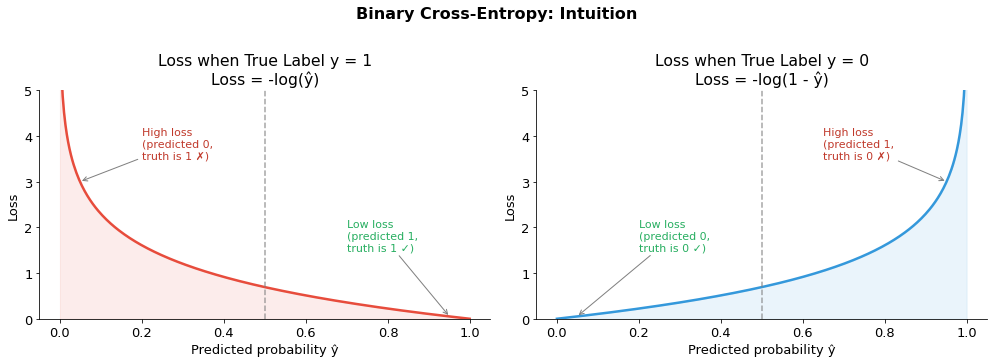

Key insight:
  When y=1 and ŷ≈1: loss ≈ 0 (correct and confident → no penalty)
  When y=1 and ŷ≈0: loss → ∞ (wrong and confident → huge penalty)
  The two cases unify neatly: L = -[y·log(ŷ) + (1-y)·log(1-ŷ)]


In [3]:
# ============================================================
# INTUITION: Why Binary Cross-Entropy?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p = np.linspace(0.001, 0.999, 300)  # predicted probability

# Case 1: True label y=1
# Loss = -log(p)  — penalize when p is low (confident wrong)
loss_y1 = -np.log(p)

ax = axes[0]
ax.plot(p, loss_y1, color='#e74c3c', linewidth=2.5)
ax.fill_between(p, loss_y1, alpha=0.1, color='#e74c3c')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7)
ax.annotate('Low loss\n(predicted 1,\ntruth is 1 ✓)', 
            xy=(0.95, 0.05), fontsize=11, color='#27ae60',
            xytext=(0.7, 1.5), arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate('High loss\n(predicted 0,\ntruth is 1 ✗)', 
            xy=(0.05, 3.0), fontsize=11, color='#c0392b',
            xytext=(0.2, 3.5), arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_xlabel('Predicted probability ŷ')
ax.set_ylabel('Loss')
ax.set_title('Loss when True Label y = 1\nLoss = -log(ŷ)')
ax.set_ylim(0, 5)

# Case 2: True label y=0
# Loss = -log(1-p)  — penalize when p is high (confident wrong)
loss_y0 = -np.log(1 - p)

ax2 = axes[1]
ax2.plot(p, loss_y0, color='#3498db', linewidth=2.5)
ax2.fill_between(p, loss_y0, alpha=0.1, color='#3498db')
ax2.axvline(0.5, color='gray', linestyle='--', alpha=0.7)
ax2.annotate('Low loss\n(predicted 0,\ntruth is 0 ✓)', 
            xy=(0.05, 0.05), fontsize=11, color='#27ae60',
            xytext=(0.2, 1.5), arrowprops=dict(arrowstyle='->', color='gray'))
ax2.annotate('High loss\n(predicted 1,\ntruth is 0 ✗)', 
            xy=(0.95, 3.0), fontsize=11, color='#c0392b',
            xytext=(0.65, 3.5), arrowprops=dict(arrowstyle='->', color='gray'))
ax2.set_xlabel('Predicted probability ŷ')
ax2.set_ylabel('Loss')
ax2.set_title('Loss when True Label y = 0\nLoss = -log(1 - ŷ)')
ax2.set_ylim(0, 5)

plt.suptitle('Binary Cross-Entropy: Intuition', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Key insight:")
print("  When y=1 and ŷ≈1: loss ≈ 0 (correct and confident → no penalty)")
print("  When y=1 and ŷ≈0: loss → ∞ (wrong and confident → huge penalty)")
print("  The two cases unify neatly: L = -[y·log(ŷ) + (1-y)·log(1-ŷ)]")

---

## ⛰️ Part 4: Gradient Descent — Training the Model

Gradient Descent is how we **minimize the loss** by updating weights.

The key gradients (derived via calculus):

$$\frac{\partial J}{\partial w} = \frac{1}{m} X^T (\hat{y} - y)$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum (\hat{y} - y)$$

Update rule (repeat until convergence):

$$w := w - \alpha \frac{\partial J}{\partial w}, \quad b := b - \alpha \frac{\partial J}{\partial b}$$

where **α (alpha)** is the **learning rate** — how big a step we take.

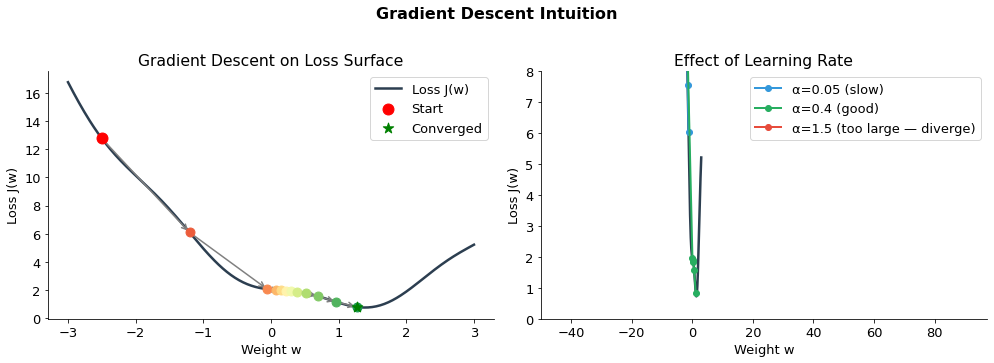

In [4]:
# ============================================================
# VISUALIZE: What is Gradient Descent?
# ============================================================

# Simulate a 1D loss surface
w_vals = np.linspace(-3, 3, 300)
J_vals = (w_vals - 1)**2 + 0.5 * np.sin(3 * w_vals) + 1  # fake bowl-shaped loss

# Simulate gradient descent steps
w_curr = -2.5
lr = 0.2
steps = []
for _ in range(12):
    J_curr = (w_curr - 1)**2 + 0.5 * np.sin(3 * w_curr) + 1
    grad = 2 * (w_curr - 1) + 1.5 * np.cos(3 * w_curr)
    steps.append((w_curr, J_curr))
    w_curr = w_curr - lr * grad

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(w_vals, J_vals, color='#2c3e50', linewidth=2.5, label='Loss J(w)')
colors_gd = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(steps)))
for i, (w, J) in enumerate(steps):
    ax.scatter(w, J, color=colors_gd[i], s=80, zorder=5)
    if i < len(steps) - 1:
        next_w, next_J = steps[i+1]
        ax.annotate('', xy=(next_w, next_J), xytext=(w, J),
                   arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.scatter(*steps[0], color='red', s=120, zorder=6, label='Start')
ax.scatter(*steps[-1], color='green', s=120, zorder=6, label='Converged', marker='*')
ax.set_xlabel('Weight w')
ax.set_ylabel('Loss J(w)')
ax.set_title('Gradient Descent on Loss Surface')
ax.legend()

# Right: show what learning rate does
ax2 = axes[1]
ax2.plot(w_vals, J_vals, color='#2c3e50', linewidth=2.5)

for lr_val, color, label in [(0.05, '#3498db', 'α=0.05 (slow)'), 
                              (0.4, '#27ae60', 'α=0.4 (good)'),
                              (1.5, '#e74c3c', 'α=1.5 (too large — diverge)')]:
    w_t = -2.5
    ws = [w_t]
    Js = [(w_t - 1)**2 + 0.5 * np.sin(3 * w_t) + 1]
    for _ in range(8):
        g = 2 * (w_t - 1) + 1.5 * np.cos(3 * w_t)
        w_t = w_t - lr_val * g
        ws.append(w_t)
        Js.append((w_t - 1)**2 + 0.5 * np.sin(3 * w_t) + 1)
    ax2.plot(ws[:6], Js[:6], 'o-', color=color, label=label, linewidth=2, markersize=6)

ax2.set_xlabel('Weight w')
ax2.set_ylabel('Loss J(w)')
ax2.set_title('Effect of Learning Rate')
ax2.legend()
ax2.set_ylim(0, 8)

plt.suptitle('Gradient Descent Intuition', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

## 🏗️ Part 5: Building Binary Logistic Regression

Now let's build the full class — clean, modular, and from scratch.

In [5]:
# ============================================================
# BINARY LOGISTIC REGRESSION — Full Implementation
# ============================================================

class LogisticRegression:
    """
    Binary Logistic Regression from scratch using NumPy.
    
    Model: ŷ = σ(W·X + b)
    Loss:  Binary Cross-Entropy
    Optimizer: Batch Gradient Descent
    """
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iters = n_iterations
        self.weights = None   # shape: (n_features,)
        self.bias = None      # scalar
        self.losses = []      # track loss per epoch

    def _sigmoid(self, z):
        """Numerically stable sigmoid."""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def _compute_loss(self, y, y_hat):
        """Binary Cross-Entropy loss."""
        m = len(y)
        # Clip to avoid log(0)
        y_hat = np.clip(y_hat, 1e-9, 1 - 1e-9)
        loss = -(1 / m) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
        return loss

    def fit(self, X, y):
        """
        Train the model using gradient descent.
        
        Parameters:
            X : np.array of shape (m, n)  — m samples, n features
            y : np.array of shape (m,)    — binary labels {0, 1}
        """
        m, n = X.shape
        
        # --- Step 1: Initialize weights to zero ---
        self.weights = np.zeros(n)  # one weight per feature
        self.bias = 0.0
        self.losses = []
        
        # --- Step 2: Gradient Descent Loop ---
        for epoch in range(self.n_iters):
            
            # Forward pass: compute predictions
            z = X @ self.weights + self.bias     # linear: shape (m,)
            y_hat = self._sigmoid(z)             # probabilities: shape (m,)
            
            # Compute loss (for tracking)
            loss = self._compute_loss(y, y_hat)
            self.losses.append(loss)
            
            # Backward pass: compute gradients
            error = y_hat - y                    # shape (m,)
            dW = (1 / m) * (X.T @ error)        # shape (n,)
            db = (1 / m) * np.sum(error)         # scalar
            
            # Update weights
            self.weights -= self.lr * dW
            self.bias    -= self.lr * db
        
        return self

    def predict_proba(self, X):
        """Return probabilities for class 1."""
        z = X @ self.weights + self.bias
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        """Return class predictions (0 or 1)."""
        return (self.predict_proba(X) >= threshold).astype(int)


print("✅ LogisticRegression class defined.")
print("\nMethod summary:")
print("  fit(X, y)           → train model")
print("  predict_proba(X)    → P(y=1|X)")
print("  predict(X)          → class labels {0, 1}")

✅ LogisticRegression class defined.

Method summary:
  fit(X, y)           → train model
  predict_proba(X)    → P(y=1|X)
  predict(X)          → class labels {0, 1}


---

## 🧪 Part 6: Training on a Real Dataset (2D example)

Let's generate a 2D binary classification dataset and train our model.

Dataset size:  200 samples
Training set:  160 samples
Test set:      40 samples
Features:      2 (exam_1_score, exam_2_score)


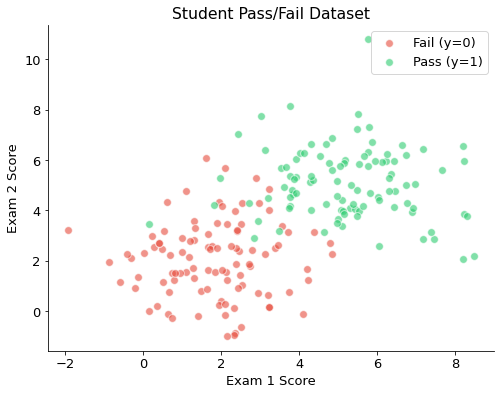

In [6]:
# ============================================================
# GENERATE BINARY DATASET
# Scenario: Predict if a student passes based on
#           exam_score_1 and exam_score_2
# ============================================================

np.random.seed(42)

# Class 0: Fail — lower scores
X0 = np.random.randn(100, 2) * 1.5 + np.array([2, 2])
y0 = np.zeros(100)

# Class 1: Pass — higher scores
X1 = np.random.randn(100, 2) * 1.5 + np.array([5, 5])
y1 = np.ones(100)

X_raw = np.vstack([X0, X1])
y     = np.hstack([y0, y1])

# --- Feature Normalization (important!) ---
# Subtract mean, divide by std so all features are on same scale
X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0)
X = (X_raw - X_mean) / X_std

# --- Train/Test split manually ---
np.random.seed(0)
idx = np.random.permutation(len(y))
split = int(0.8 * len(y))
train_idx, test_idx = idx[:split], idx[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Dataset size:  {len(X)} samples")
print(f"Training set:  {len(X_train)} samples")
print(f"Test set:      {len(X_test)} samples")
print(f"Features:      {X.shape[1]} (exam_1_score, exam_2_score)")

# --- Visualize raw data ---
plt.figure(figsize=(8, 6))
plt.scatter(X_raw[y==0, 0], X_raw[y==0, 1], 
            alpha=0.6, color='#e74c3c', label='Fail (y=0)', edgecolors='white', s=60)
plt.scatter(X_raw[y==1, 0], X_raw[y==1, 1], 
            alpha=0.6, color='#2ecc71', label='Pass (y=1)', edgecolors='white', s=60)
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.title('Student Pass/Fail Dataset')
plt.legend()
plt.show()

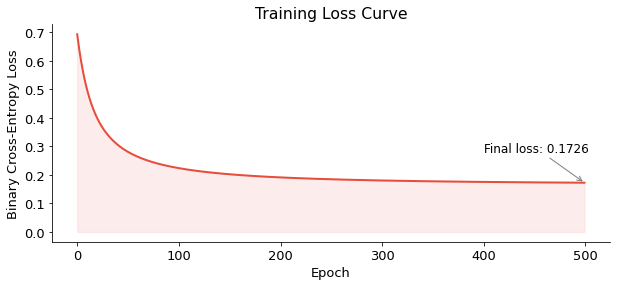

Learned weights: [2.28167464 2.16770446]
Learned bias:    -0.0459
Initial loss:    0.6931
Final loss:      0.1726


In [7]:
# ============================================================
# TRAIN THE MODEL
# ============================================================

model = LogisticRegression(learning_rate=0.1, n_iterations=500)
model.fit(X_train, y_train)

# --- Plot training loss curve ---
plt.figure(figsize=(10, 4))
plt.plot(model.losses, color='#e74c3c', linewidth=2)
plt.fill_between(range(len(model.losses)), model.losses, alpha=0.1, color='#e74c3c')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training Loss Curve')
plt.annotate(f'Final loss: {model.losses[-1]:.4f}', 
             xy=(len(model.losses)-1, model.losses[-1]),
             xytext=(400, model.losses[50]),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=12)
plt.show()

print(f"Learned weights: {model.weights}")
print(f"Learned bias:    {model.bias:.4f}")
print(f"Initial loss:    {model.losses[0]:.4f}")
print(f"Final loss:      {model.losses[-1]:.4f}")

---

## 🎯 Part 7: Decision Boundary Visualization

The decision boundary is where **ŷ = 0.5**, i.e., where **W·X + b = 0** (because σ(0) = 0.5).

For 2 features: `w₁x₁ + w₂x₂ + b = 0` → `x₂ = -(w₁x₁ + b) / w₂`

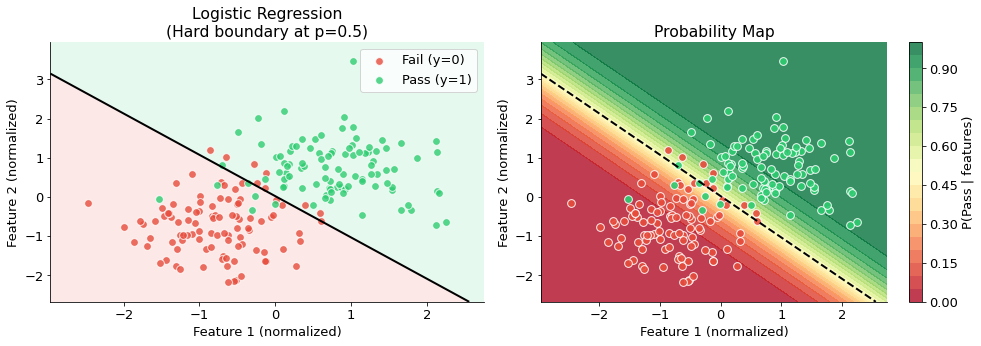

In [8]:
# ============================================================
# DECISION BOUNDARY + PROBABILITY CONTOURS
# ============================================================

def plot_decision_boundary(model, X, y, title='Decision Boundary'):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid).reshape(xx.shape)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Hard boundary
    ax = axes[0]
    ax.contourf(xx, yy, probs, levels=[0, 0.5, 1],
                colors=['#fadbd8', '#d5f5e3'], alpha=0.6)
    ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X[y==0, 0], X[y==0, 1], color='#e74c3c', edgecolors='white',
               s=60, alpha=0.8, label='Fail (y=0)')
    ax.scatter(X[y==1, 0], X[y==1, 1], color='#2ecc71', edgecolors='white',
               s=60, alpha=0.8, label='Pass (y=1)')
    ax.set_title(f'{title}\n(Hard boundary at p=0.5)')
    ax.legend()
    ax.set_xlabel('Feature 1 (normalized)')
    ax.set_ylabel('Feature 2 (normalized)')
    
    # Right: Probability contours
    ax2 = axes[1]
    cp = ax2.contourf(xx, yy, probs, levels=20, cmap='RdYlGn', alpha=0.8)
    plt.colorbar(cp, ax=ax2, label='P(Pass | features)')
    ax2.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    ax2.scatter(X[y==0, 0], X[y==0, 1], color='#e74c3c', edgecolors='white', s=60, alpha=0.9)
    ax2.scatter(X[y==1, 0], X[y==1, 1], color='#2ecc71', edgecolors='white', s=60, alpha=0.9)
    ax2.set_title('Probability Map')
    ax2.set_xlabel('Feature 1 (normalized)')
    ax2.set_ylabel('Feature 2 (normalized)')
    
    plt.tight_layout()
    plt.show()

plot_decision_boundary(model, X, y, title='Logistic Regression')

---

## 📊 Part 8: Evaluation Metrics From Scratch

Accuracy alone isn't enough. Let's build a complete evaluation toolkit.

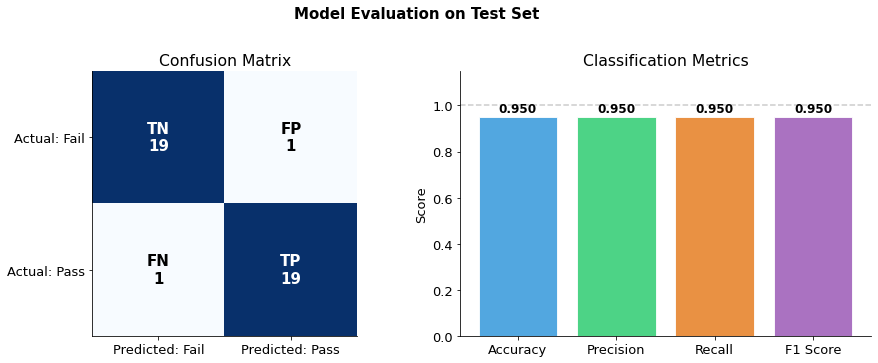


Metrics explained:
  Accuracy  = (TP+TN) / total          — overall correctness
  Precision = TP / (TP+FP)             — of all predicted positives, how many are real
  Recall    = TP / (TP+FN)             — of all real positives, how many did we catch
  F1        = 2*P*R / (P+R)            — harmonic mean of precision and recall


In [9]:
# ============================================================
# EVALUATION METRICS — all from scratch
# ============================================================

def compute_metrics(y_true, y_pred, y_prob):
    """Compute classification metrics from scratch."""
    
    # --- Confusion matrix components ---
    TP = np.sum((y_pred == 1) & (y_true == 1))  # predicted 1, actual 1
    TN = np.sum((y_pred == 0) & (y_true == 0))  # predicted 0, actual 0
    FP = np.sum((y_pred == 1) & (y_true == 0))  # predicted 1, actual 0 (false alarm)
    FN = np.sum((y_pred == 0) & (y_true == 1))  # predicted 0, actual 1 (missed)
    
    accuracy  = (TP + TN) / len(y_true)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'confusion': np.array([[TN, FP], [FN, TP]]),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }


# Evaluate on test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)
metrics = compute_metrics(y_test, y_pred, y_prob)

# --- Plot: Confusion Matrix + Metrics ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = metrics['confusion']
ax = axes[0]
im = ax.imshow(cm, cmap='Blues')
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i][j]}\n{cm[i, j]}",
                ha='center', va='center', fontsize=15,
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontweight='bold')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: Fail', 'Predicted: Pass'])
ax.set_yticklabels(['Actual: Fail', 'Actual: Pass'])
ax.set_title('Confusion Matrix')

# Metrics Bar Chart
ax2 = axes[1]
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_values = [metrics['accuracy'], metrics['precision'], 
                 metrics['recall'], metrics['f1']]
colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
bars = ax2.bar(metric_names, metric_values, color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, metric_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax2.set_ylim(0, 1.15)
ax2.set_title('Classification Metrics')
ax2.set_ylabel('Score')
ax2.axhline(1.0, color='gray', linestyle='--', alpha=0.4)

plt.suptitle('Model Evaluation on Test Set', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nMetrics explained:")
print("  Accuracy  = (TP+TN) / total          — overall correctness")
print("  Precision = TP / (TP+FP)             — of all predicted positives, how many are real")
print("  Recall    = TP / (TP+FN)             — of all real positives, how many did we catch")
print("  F1        = 2*P*R / (P+R)            — harmonic mean of precision and recall")

---

## 🔬 Part 9: Effect of Learning Rate & Iterations

Let's explore how hyperparameters affect training.

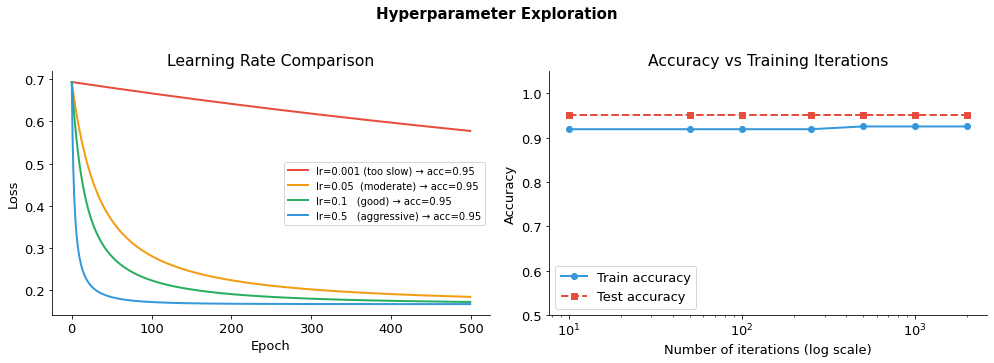

In [10]:
# ============================================================
# HYPERPARAMETER COMPARISON
# ============================================================

configs = [
    {'lr': 0.001, 'n': 500, 'label': 'lr=0.001 (too slow)', 'color': '#e74c3c'},
    {'lr': 0.05,  'n': 500, 'label': 'lr=0.05  (moderate)',  'color': '#f39c12'},
    {'lr': 0.1,   'n': 500, 'label': 'lr=0.1   (good)',      'color': '#27ae60'},
    {'lr': 0.5,   'n': 500, 'label': 'lr=0.5   (aggressive)','color': '#3498db'},
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for cfg in configs:
    m = LogisticRegression(learning_rate=cfg['lr'], n_iterations=cfg['n'])
    m.fit(X_train, y_train)
    acc = np.mean(m.predict(X_test) == y_test)
    ax.plot(m.losses, color=cfg['color'], linewidth=2,
            label=f"{cfg['label']} → acc={acc:.2f}")

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Learning Rate Comparison')
ax.legend(fontsize=10)

# Iterations comparison
ax2 = axes[1]
iter_counts = [10, 50, 100, 250, 500, 1000, 2000]
accs_train, accs_test = [], []

for n_iter in iter_counts:
    m = LogisticRegression(learning_rate=0.1, n_iterations=n_iter)
    m.fit(X_train, y_train)
    accs_train.append(np.mean(m.predict(X_train) == y_train))
    accs_test.append(np.mean(m.predict(X_test) == y_test))

ax2.semilogx(iter_counts, accs_train, 'o-', color='#3498db', linewidth=2, label='Train accuracy')
ax2.semilogx(iter_counts, accs_test,  's--', color='#e74c3c', linewidth=2, label='Test accuracy')
ax2.set_xlabel('Number of iterations (log scale)')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy vs Training Iterations')
ax2.legend()
ax2.set_ylim(0.5, 1.05)

plt.suptitle('Hyperparameter Exploration', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

## 🌐 Part 10: Multinomial Logistic Regression (Softmax)

When there are **K > 2 classes**, we extend binary logistic regression to use the **Softmax function**.

Instead of one weight vector, we have **K weight vectors** — one per class.

**Softmax formula** (converts raw scores to probabilities over K classes):

$$P(y=k | X) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

**Loss: Categorical Cross-Entropy**

$$J = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_k^{(i)} \log(\hat{p}_k^{(i)})$$

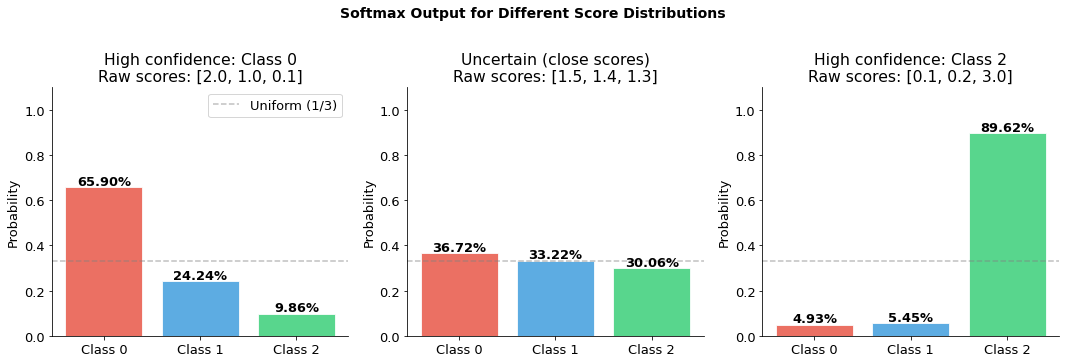

Softmax output: [[0.659  0.2424 0.0986]
 [0.3333 0.3333 0.3333]]
Row sums (should be 1.0): [1. 1.]


In [11]:
# ============================================================
# SOFTMAX FUNCTION — Intuition & Visualization
# ============================================================

def softmax(z):
    """
    Softmax: turns raw scores into probabilities summing to 1.
    Numerically stable: subtract max before exponentiating.
    
    Parameters:
        z : np.array of shape (m, K)
    Returns:
        np.array of shape (m, K) — probabilities
    """
    # Subtract max per row for numerical stability
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


# --- Visualize: How Softmax works ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

examples = [
    ([2.0, 1.0, 0.1], 'High confidence: Class 0'),
    ([1.5, 1.4, 1.3], 'Uncertain (close scores)'),
    ([0.1, 0.2, 3.0], 'High confidence: Class 2'),
]

for ax, (scores, title) in zip(axes, examples):
    scores = np.array(scores)
    probs  = softmax(scores.reshape(1, -1)).flatten()
    classes = ['Class 0', 'Class 1', 'Class 2']
    colors  = ['#e74c3c', '#3498db', '#2ecc71']
    
    bars = ax.bar(classes, probs, color=colors, alpha=0.8, edgecolor='white')
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{p:.2%}', ha='center', fontweight='bold')
    
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Probability')
    ax.set_title(f'{title}\nRaw scores: {list(scores)}')
    ax.axhline(1/3, color='gray', linestyle='--', alpha=0.5, label='Uniform (1/3)')

axes[0].legend()
plt.suptitle('Softmax Output for Different Score Distributions', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Verify probabilities sum to 1
test_scores = np.array([[2.0, 1.0, 0.1], [0.5, 0.5, 0.5]])
probs = softmax(test_scores)
print("Softmax output:", np.round(probs, 4))
print("Row sums (should be 1.0):", probs.sum(axis=1))

In [12]:
# ============================================================
# ONE-HOT ENCODING — needed for multi-class labels
# ============================================================

def one_hot_encode(y, n_classes):
    """
    Convert integer labels to one-hot vectors.
    
    Example: y=2, n_classes=3 → [0, 0, 1]
    """
    m = len(y)
    Y_onehot = np.zeros((m, n_classes))
    Y_onehot[np.arange(m), y.astype(int)] = 1
    return Y_onehot


# Demo
y_demo = np.array([0, 1, 2, 1, 0])
Y_oh   = one_hot_encode(y_demo, n_classes=3)

print("Integer labels:")
print(y_demo)
print("\nOne-hot encoded:")
print(Y_oh)
print("\nColumn meaning: [Class_0, Class_1, Class_2]")

Integer labels:
[0 1 2 1 0]

One-hot encoded:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]

Column meaning: [Class_0, Class_1, Class_2]


In [13]:
# ============================================================
# MULTINOMIAL LOGISTIC REGRESSION — Full Implementation
# ============================================================

class MultinomialLogisticRegression:
    """
    Multi-class Logistic Regression using Softmax.
    
    Model:  Z = X @ W + b           (m × K)
            P = softmax(Z)          (m × K) — probabilities per class
    Loss:   Categorical Cross-Entropy
    Optimizer: Batch Gradient Descent
    """
    
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iters = n_iterations
        self.W = None       # shape: (n_features, K)
        self.b = None       # shape: (K,)
        self.losses = []
        self.K = None       # number of classes

    def _softmax(self, z):
        z_shifted = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _compute_loss(self, Y_onehot, P):
        """Categorical Cross-Entropy."""
        m = len(Y_onehot)
        P_clipped = np.clip(P, 1e-9, 1 - 1e-9)
        return -(1 / m) * np.sum(Y_onehot * np.log(P_clipped))

    def fit(self, X, y):
        """
        Train using gradient descent.
        
        Parameters:
            X : (m, n) — m samples, n features
            y : (m,)   — integer class labels {0, 1, ..., K-1}
        """
        m, n = X.shape
        self.K = len(np.unique(y))
        
        # Initialize weights — small random values (not zeros for multiclass)
        self.W = np.random.randn(n, self.K) * 0.01  # (n, K)
        self.b = np.zeros(self.K)                    # (K,)
        self.losses = []
        
        # One-hot encode labels
        Y = one_hot_encode(y, self.K)  # (m, K)
        
        for epoch in range(self.n_iters):
            # Forward pass
            Z = X @ self.W + self.b      # (m, K) — raw scores
            P = self._softmax(Z)         # (m, K) — probabilities
            
            # Loss
            loss = self._compute_loss(Y, P)
            self.losses.append(loss)
            
            # Backward pass
            # Gradient of cross-entropy + softmax combined is elegant:
            # dL/dZ = (P - Y) / m
            dZ = (P - Y) / m             # (m, K)
            dW = X.T @ dZ                # (n, K)
            db = np.sum(dZ, axis=0)      # (K,)
            
            # Update
            self.W -= self.lr * dW
            self.b -= self.lr * db
        
        return self

    def predict_proba(self, X):
        """Return class probabilities. Shape: (m, K)"""
        Z = X @ self.W + self.b
        return self._softmax(Z)

    def predict(self, X):
        """Return class with highest probability."""
        return np.argmax(self.predict_proba(X), axis=1)


print("✅ MultinomialLogisticRegression defined.")
print("\nKey differences from binary:")
print("  - W shape: (n_features, K)  not (n_features,)")
print("  - Uses softmax instead of sigmoid")
print("  - Loss: Categorical cross-entropy")
print("  - Labels must be one-hot encoded internally")

✅ MultinomialLogisticRegression defined.

Key differences from binary:
  - W shape: (n_features, K)  not (n_features,)
  - Uses softmax instead of sigmoid
  - Loss: Categorical cross-entropy
  - Labels must be one-hot encoded internally


---

## 🌸 Part 11: Multi-class Classification Demo

Let's train on a 3-class dataset and visualize the multi-class decision regions.

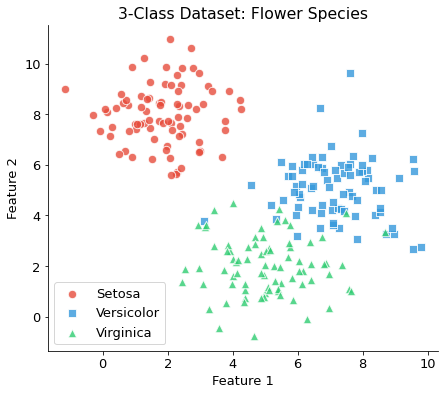

Dataset: 240 samples, 3 classes


In [14]:
# ============================================================
# GENERATE 3-CLASS DATASET
# Scenario: 3 flower species by petal dimensions
# ============================================================

np.random.seed(42)

# Three clusters in 2D
centers = np.array([[2, 8], [7, 5], [5, 2]])
n_per_class = 80

X_mc_list, y_mc_list = [], []
for k, center in enumerate(centers):
    X_mc_list.append(np.random.randn(n_per_class, 2) * 1.2 + center)
    y_mc_list.append(np.full(n_per_class, k))

X_mc_raw = np.vstack(X_mc_list)
y_mc = np.hstack(y_mc_list)

# Normalize
X_mc = (X_mc_raw - X_mc_raw.mean(axis=0)) / X_mc_raw.std(axis=0)

# Train/test split
idx = np.random.permutation(len(y_mc))
split = int(0.8 * len(y_mc))
X_mc_train, X_mc_test = X_mc[idx[:split]], X_mc[idx[split:]]
y_mc_train, y_mc_test = y_mc[idx[:split]], y_mc[idx[split:]]

# --- Plot raw data ---
colors3 = ['#e74c3c', '#3498db', '#2ecc71']
labels3 = ['Setosa', 'Versicolor', 'Virginica']
markers3 = ['o', 's', '^']

plt.figure(figsize=(7, 6))
for k in range(3):
    mask = y_mc == k
    plt.scatter(X_mc_raw[mask, 0], X_mc_raw[mask, 1],
                color=colors3[k], label=labels3[k],
                marker=markers3[k], s=70, alpha=0.8, edgecolors='white')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('3-Class Dataset: Flower Species')
plt.legend()
plt.show()

print(f"Dataset: {len(X_mc)} samples, 3 classes")

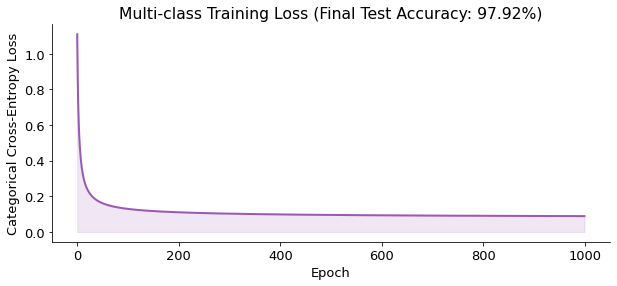

Weight matrix W shape: (2, 3)  (n_features × K)
Bias shape:            (3,)
Test accuracy:         97.92%


In [16]:
# ============================================================
# TRAIN MULTI-CLASS MODEL
# ============================================================

mc_model = MultinomialLogisticRegression(learning_rate=0.5, n_iterations=1000)
mc_model.fit(X_mc_train, y_mc_train)

# Evaluate
y_mc_pred = mc_model.predict(X_mc_test)
test_acc = np.mean(y_mc_pred == y_mc_test)

# --- Loss curve ---
plt.figure(figsize=(10, 4))
plt.plot(mc_model.losses, color='#9b59b6', linewidth=2)
plt.fill_between(range(len(mc_model.losses)), mc_model.losses, alpha=0.15, color='#9b59b6')
plt.xlabel('Epoch')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.title(f'Multi-class Training Loss (Final Test Accuracy: {test_acc:.2%})')
plt.show()

print(f"Weight matrix W shape: {mc_model.W.shape}  (n_features × K)")
print(f"Bias shape:            {mc_model.b.shape}")
print(f"Test accuracy:         {test_acc:.2%}")

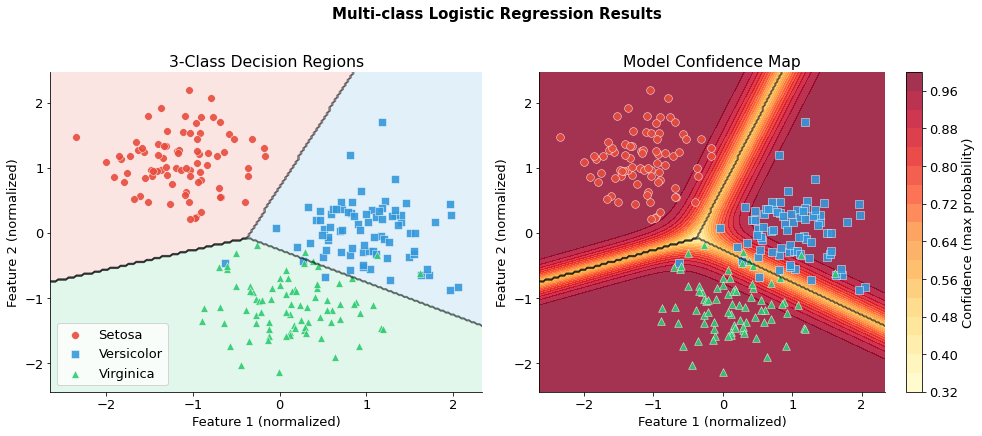

In [17]:
# ============================================================
# MULTI-CLASS DECISION REGIONS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

h = 0.03
x_min, x_max = X_mc[:, 0].min() - 0.3, X_mc[:, 0].max() + 0.3
y_min, y_max = X_mc[:, 1].min() - 0.3, X_mc[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

preds_grid = mc_model.predict(grid).reshape(xx.shape)
proba_grid = mc_model.predict_proba(grid)

# Left: Hard decision regions
ax = axes[0]
cmap = ListedColormap(['#fadbd8', '#d6eaf8', '#d5f5e3'])
ax.contourf(xx, yy, preds_grid, cmap=cmap, alpha=0.7)
ax.contour(xx, yy, preds_grid, colors='black', linewidths=0.8, alpha=0.4)
for k in range(3):
    mask = y_mc == k
    ax.scatter(X_mc[mask, 0], X_mc[mask, 1],
               color=colors3[k], label=labels3[k],
               marker=markers3[k], s=60, alpha=0.9, edgecolors='white', linewidths=0.5)
ax.set_title('3-Class Decision Regions')
ax.legend()
ax.set_xlabel('Feature 1 (normalized)')
ax.set_ylabel('Feature 2 (normalized)')

# Right: Confidence map for each class
ax2 = axes[1]
max_proba = proba_grid.max(axis=1).reshape(xx.shape)
cp = ax2.contourf(xx, yy, max_proba, levels=20, cmap='YlOrRd', alpha=0.8)
plt.colorbar(cp, ax=ax2, label='Confidence (max probability)')
ax2.contour(xx, yy, preds_grid, colors='black', linewidths=0.8, alpha=0.4)
for k in range(3):
    mask = y_mc == k
    ax2.scatter(X_mc[mask, 0], X_mc[mask, 1],
                color=colors3[k], marker=markers3[k],
                s=60, alpha=0.9, edgecolors='white', linewidths=0.5)
ax2.set_title('Model Confidence Map')
ax2.set_xlabel('Feature 1 (normalized)')
ax2.set_ylabel('Feature 2 (normalized)')

plt.suptitle('Multi-class Logistic Regression Results', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

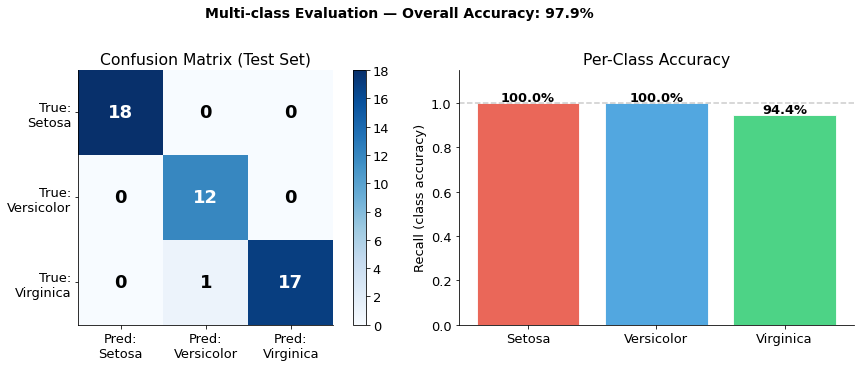

In [18]:
# ============================================================
# MULTI-CLASS CONFUSION MATRIX
# ============================================================

def confusion_matrix_mc(y_true, y_pred, K):
    """Build K×K confusion matrix from scratch."""
    cm = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true.astype(int), y_pred.astype(int)):
        cm[t, p] += 1
    return cm


cm3 = confusion_matrix_mc(y_mc_test, y_mc_pred, K=3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
ax = axes[0]
im = ax.imshow(cm3, cmap='Blues')
plt.colorbar(im, ax=ax)
for i in range(3):
    for j in range(3):
        color = 'white' if cm3[i, j] > cm3.max() * 0.6 else 'black'
        ax.text(j, i, str(cm3[i, j]), ha='center', va='center',
                fontsize=18, fontweight='bold', color=color)
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels([f'Pred:\n{l}' for l in labels3])
ax.set_yticklabels([f'True:\n{l}' for l in labels3])
ax.set_title('Confusion Matrix (Test Set)')

# Per-class accuracy
ax2 = axes[1]
per_class_acc = cm3.diagonal() / cm3.sum(axis=1)
bars = ax2.bar(labels3, per_class_acc, color=colors3, alpha=0.85, edgecolor='white')
for bar, acc in zip(bars, per_class_acc):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.1%}', ha='center', fontweight='bold', fontsize=13)
ax2.set_ylim(0, 1.15)
ax2.set_title('Per-Class Accuracy')
ax2.set_ylabel('Recall (class accuracy)')
ax2.axhline(1.0, color='gray', linestyle='--', alpha=0.4)

plt.suptitle(f'Multi-class Evaluation — Overall Accuracy: {test_acc:.1%}',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

## 🔁 Part 12: Full Comparison — Binary vs Multi-class

A side-by-side summary of the two models.

In [19]:
# ============================================================
# COMPARISON SUMMARY TABLE
# ============================================================

print("=" * 70)
print(f"{'':25} {'Binary LR':20} {'Multinomial LR':20}")
print("=" * 70)

rows = [
    ("Output function",       "Sigmoid σ(z)",          "Softmax(Z)"),
    ("Output shape",          "(m,) scalar",           "(m, K) vector"),
    ("Weights shape",         "(n_features,)",         "(n_features, K)"),
    ("Bias shape",            "scalar",                "(K,)"),
    ("Loss function",         "Binary Cross-Entropy",  "Categorical Cross-Entropy"),
    ("Prediction",            "argmax over {0,1}",     "argmax over K classes"),
    ("Classes",               "2",                     "K ≥ 2"),
    ("Label format",          "0 or 1",                "Integer or one-hot"),
    ("Gradient dW",           "Xᵀ(ŷ-y)/m",            "Xᵀ(P-Y)/m"),
]

for label, binary, multi in rows:
    print(f"  {label:23} {binary:20} {multi:20}")

print("=" * 70)
print("\nKey insight:")
print("  Multinomial LR is a direct generalization of Binary LR.")
print("  When K=2, Softmax = Sigmoid (they are equivalent!)")

                          Binary LR            Multinomial LR      
  Output function         Sigmoid σ(z)         Softmax(Z)          
  Output shape            (m,) scalar          (m, K) vector       
  Weights shape           (n_features,)        (n_features, K)     
  Bias shape              scalar               (K,)                
  Loss function           Binary Cross-Entropy Categorical Cross-Entropy
  Prediction              argmax over {0,1}    argmax over K classes
  Classes                 2                    K ≥ 2               
  Label format            0 or 1               Integer or one-hot  
  Gradient dW             Xᵀ(ŷ-y)/m            Xᵀ(P-Y)/m           

Key insight:
  Multinomial LR is a direct generalization of Binary LR.
  When K=2, Softmax = Sigmoid (they are equivalent!)


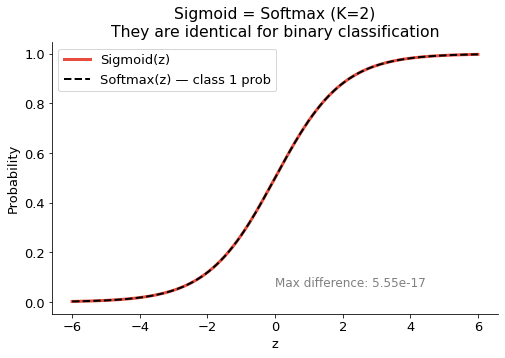

Max difference between sigmoid and softmax: 5.55e-17
They are numerically equivalent! ✅


In [20]:
# ============================================================
# PROOF: Softmax with K=2 equals Sigmoid
# ============================================================

z_binary = np.linspace(-6, 6, 200)

# Binary sigmoid
sig_out = 1 / (1 + np.exp(-z_binary))

# Softmax with 2 classes (class 0 score=0, class 1 score=z)
Z_two = np.column_stack([np.zeros_like(z_binary), z_binary])
soft_out = softmax(Z_two)[:, 1]  # probability of class 1

plt.figure(figsize=(8, 5))
plt.plot(z_binary, sig_out, color='#e74c3c', linewidth=3, label='Sigmoid(z)')
plt.plot(z_binary, soft_out, 'k--', linewidth=2, label='Softmax(z) — class 1 prob')
plt.xlabel('z')
plt.ylabel('Probability')
plt.title('Sigmoid = Softmax (K=2)\nThey are identical for binary classification')
plt.legend()
max_diff = np.max(np.abs(sig_out - soft_out))
plt.annotate(f'Max difference: {max_diff:.2e}', xy=(0.5, 0.1),
             xycoords='axes fraction', fontsize=12, color='gray')
plt.show()

print(f"Max difference between sigmoid and softmax: {max_diff:.2e}")
print("They are numerically equivalent! ✅")

---

## 🚀 Part 13: Putting It All Together — End-to-End Pipeline

A clean, reusable pipeline that wraps preprocessing + training + evaluation.

In [21]:
# ============================================================
# CLEAN PIPELINE: Normalize → Split → Train → Evaluate
# ============================================================

class Pipeline:
    """A minimal ML pipeline: normalize → train → evaluate."""
    
    def __init__(self, model):
        self.model = model
        self.mean_ = None
        self.std_ = None
    
    def normalize(self, X, fit=True):
        if fit:
            self.mean_ = X.mean(axis=0)
            self.std_ = X.std(axis=0)
        return (X - self.mean_) / self.std_
    
    def train_test_split(self, X, y, test_size=0.2, seed=42):
        np.random.seed(seed)
        idx = np.random.permutation(len(y))
        split = int((1 - test_size) * len(y))
        return X[idx[:split]], X[idx[split:]], y[idx[:split]], y[idx[split:]]
    
    def run(self, X_raw, y):
        # Normalize
        X = self.normalize(X_raw, fit=True)
        
        # Split
        X_tr, X_te, y_tr, y_te = self.train_test_split(X, y)
        
        # Train
        self.model.fit(X_tr, y_tr)
        
        # Evaluate
        y_pred = self.model.predict(X_te)
        acc = np.mean(y_pred == y_te)
        
        return {'accuracy': acc, 'model': self.model,
                'X_test': X_te, 'y_test': y_te, 'y_pred': y_pred}


# --- Run Binary Pipeline ---
print("=== Binary Logistic Regression Pipeline ===")
binary_pipe = Pipeline(LogisticRegression(learning_rate=0.1, n_iterations=500))
binary_result = binary_pipe.run(X_raw, y)
print(f"Test Accuracy: {binary_result['accuracy']:.2%}")

print()
print("=== Multi-class Logistic Regression Pipeline ===")
multi_pipe = Pipeline(MultinomialLogisticRegression(learning_rate=0.5, n_iterations=500))
multi_result = multi_pipe.run(X_mc_raw, y_mc)
print(f"Test Accuracy: {multi_result['accuracy']:.2%}")

=== Binary Logistic Regression Pipeline ===
Test Accuracy: 95.00%

=== Multi-class Logistic Regression Pipeline ===
Test Accuracy: 93.75%


---

## 📝 Summary & Key Takeaways

Congratulations! You've built logistic regression from the ground up.

### What we built:
| Component | Binary | Multi-class |
|-----------|--------|-------------|
| Core function | Sigmoid | Softmax |
| Loss | Binary Cross-Entropy | Categorical Cross-Entropy |
| Gradient of W | Xᵀ(ŷ-y)/m | Xᵀ(P-Y)/m |
| Output | Probability for class 1 | Probability vector over K classes |

### Core equations:
```
Binary:      z = W·X + b   →   ŷ = σ(z) = 1/(1+e⁻ᶻ)
Multi-class: Z = X@W + b   →   P = softmax(Z)
```

### Key concepts:
1. **Sigmoid** squashes any value to (0,1) — perfect for probabilities
2. **Binary Cross-Entropy** penalizes confident wrong predictions exponentially
3. **Gradient Descent** iteratively moves weights in the direction that reduces loss
4. **Softmax** generalizes sigmoid to K classes and ensures probabilities sum to 1
5. **Feature normalization** is critical for gradient descent convergence

### What's next:
- Add **L2 regularization** to prevent overfitting: `J += (λ/2m) * ||W||²`
- Implement **mini-batch gradient descent** for large datasets
- Explore **non-linear boundaries** by adding feature engineering or neural networks

---
*Built from scratch with NumPy only.*